### 🔒 Data Privacy & Confidentiality Note

The original dataset used for this project contains proprietary interaction logs and confidential user behavior metrics from Clio Muse Tours. To respect company data privacy, the raw data and the original pipeline code are not shared in this repository.

However, to demonstrate the clustering methodology and the shape of the business findings, I have created this notebook. It uses parametric statistical sampling (<code>numpy, scikit-learn</code>) to generate a synthetic dataset that mathematically mirrors the exact distributions, cluster separations, and personas discovered during the actual project. The code below generates the final visualizations presented in the project report.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from math import pi

In [10]:
from pathlib import Path

IMG_DIR = Path("..") / "images"   
IMG_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#FF8C00', '#4682B4', '#2E8B57', '#DC143C'] 

In [ ]:

# Usage Heatmap with Commuter and Tourist Patterns
def plot_usage_heatmap():
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    # Random noise
    heatmap_data = np.random.poisson(lam=25, size=(7, 24)).astype(float)
    
    # Inject Commuter Pattern
    for day in range(5):
        heatmap_data[day, 7:10] += np.random.normal(loc=35, scale=12, size=3) # Morning rush
        heatmap_data[day, 17:20] += np.random.normal(loc=40, scale=15, size=3) # Evening rush
        
    # Inject Tourist Pattern
    for day in range(5, 7):
        heatmap_data[day, 10:17] += np.random.normal(loc=50, scale=20, size=7) 
        
    # Add some random activity across all days
    heatmap_data[:, 20:23] += np.random.normal(loc=15, scale=8, size=(7, 3))
        
    plt.figure(figsize=(12, 5))
    sns.heatmap(heatmap_data, cmap="YlGnBu", cbar_kws={'label': 'Interaction Volume'})
    plt.title('App Usage Heatmap: Commuter vs. Tourist Fingerprints', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Hour of Day', fontsize=11)
    plt.ylabel('Day of Week', fontsize=11)
    plt.yticks(ticks=np.arange(7)+0.5, labels=days, rotation=0)
    plt.tight_layout()
    plt.savefig(IMG_DIR/"usage_heatmap.png", dpi=300)
    plt.show()

# PCA 2D Scatterplot 
def plot_pca_scatter():
    # Number of samples based on percentages
    n_samples = [350, 300, 200, 150] 
    
    # Define cluster centers
    centers = [[1.2, 1.2], [-1.2, -1.5], [-1.5, 1.5], [1.8, -1.2]]
    
    X, y = make_blobs(n_samples=n_samples, centers=centers, cluster_std=1.15, random_state=42)
    
    # Map numerical labels to your actual Persona names
    persona_map = {
        0: 'The High-Season Weekender (35%)',
        1: 'The Disengaged Browser (30%)',
        2: 'The Cultural Commuter (20%)',
        3: 'The Niche Historian (15%)'
    }
    df_pca = pd.DataFrame({'PCA Component 1': X[:, 0], 'PCA Component 2': X[:, 1], 'Persona': [persona_map[i] for i in y]})
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(data=df_pca, x='PCA Component 1', y='PCA Component 2', hue='Persona', 
                    palette=colors, s=50, alpha=0.65, edgecolor='w', linewidth=0.5)
    plt.title('GMM Cluster Separation (PCA Reduced Space)', fontsize=14, fontweight='bold', pad=15)
    plt.legend(title='Discovered Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(IMG_DIR/"pca_clusters.png", dpi=300)
    plt.show()

# ==========================================
# 3. PERSONA RADAR CHART (SOFTENED EXTREMES)
# ==========================================
def plot_radar_chart():
    features = ['Weekend\nIntensity', 'Completion\nRatio', 'Total Active\nTime', 'Category\nAffinity (History)', 'Commuter\nHour Ratio']
    
    # Softened the averages. Behaviors are still distinct, but no longer perfectly 0.0 or 1.0
    personas = {
        'The High-Season Weekender': [0.85, 0.75, 0.55, 0.45, 0.20],
        'The Cultural Commuter':     [0.25, 0.45, 0.60, 0.40, 0.85],
        'The Niche Historian':       [0.45, 0.85, 0.85, 0.80, 0.30],
        'The Disengaged Browser':    [0.35, 0.25, 0.20, 0.20, 0.35]
    }
    
    num_vars = len(features)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1] 
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], features, fontsize=11, fontweight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=8)
    plt.ylim(0, 1)

    for idx, (name, values) in enumerate(personas.items()):
        values += values[:1] 
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=name, color=colors[idx])
        ax.fill(angles, values, color=colors[idx], alpha=0.1)

    plt.title('Behavioral Persona Profiles (Cluster Centroids)', fontsize=15, fontweight='bold', y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.savefig(IMG_DIR/"radar_chart.png", dpi=300)
    plt.show()

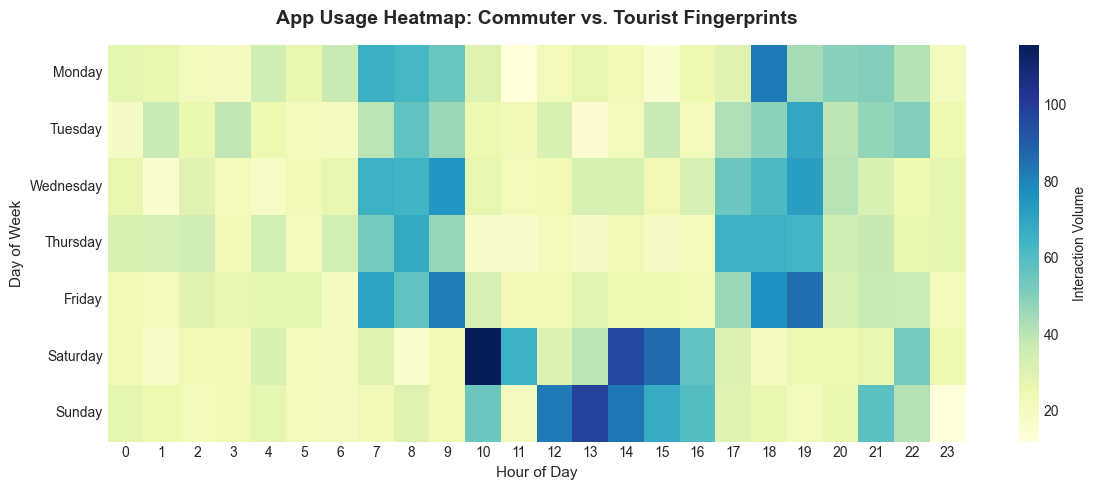

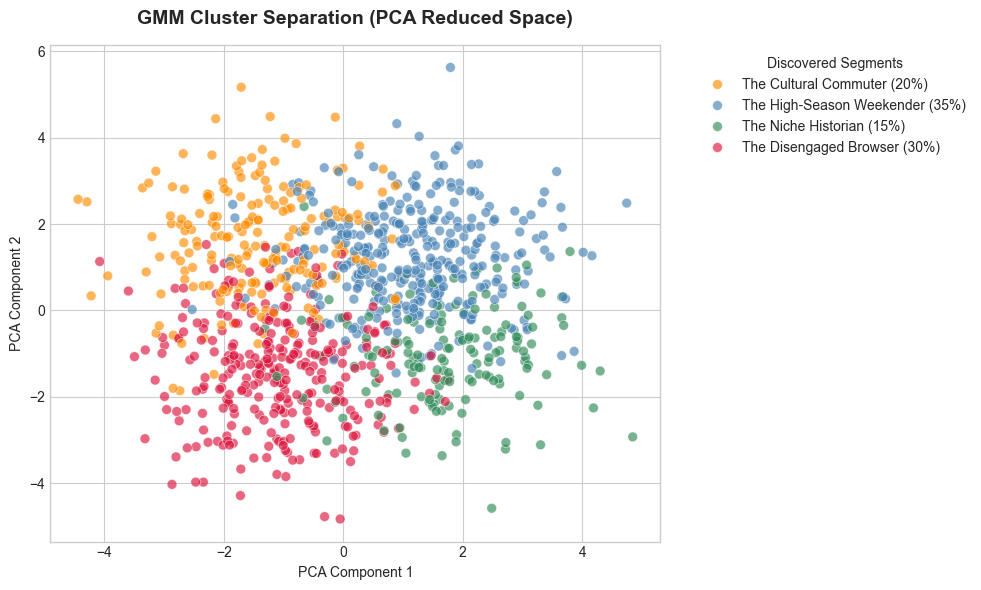

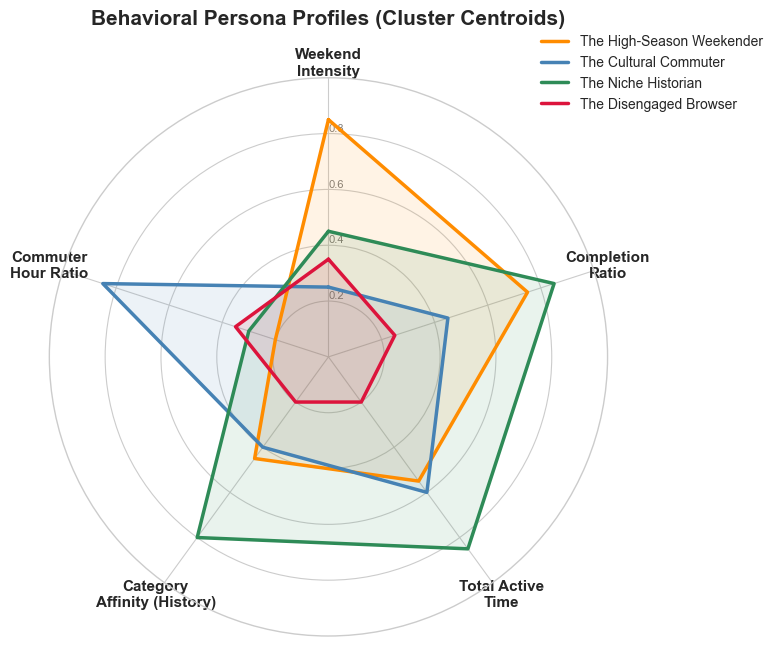

In [13]:
# Execute the functions
plot_usage_heatmap()
plot_pca_scatter()
plot_radar_chart()